Original Data:

    Age  Income  SpendingScore
0    25   40000             60
1    30   50000             65
2    35   60000             70
3    40   80000             30
4    45   90000             25
5    50  100000             20
6    23   38000             75
7    27   42000             80
8    33   58000             68
9    48   85000             22
10   52  110000             18
11   29   46000             72
12   31   52000             66
13   37   62000             55
14   42   78000             35

Mean:
 [3.64666667e+01 6.60666667e+04 5.07333333e+01]

Standard Deviation:
 [9.01011777e+00 2.21704508e+04 2.20437948e+01]

Standardized Data:
 [[-1.27264337 -1.17573914  0.42037529]
 [-0.71771167 -0.72468832  0.64719649]
 [-0.16277997 -0.2736375   0.87401769]
 [ 0.39215174  0.62846414 -0.94055191]
 [ 0.94708344  1.07951496 -1.16737311]
 [ 1.50201514  1.53056578 -1.39419431]
 [-1.49461605 -1.2659493   1.10083889]
 [-1.05067069 -1.08552897  1.32766009]
 [-0.38475265 -0.36384766  0.78

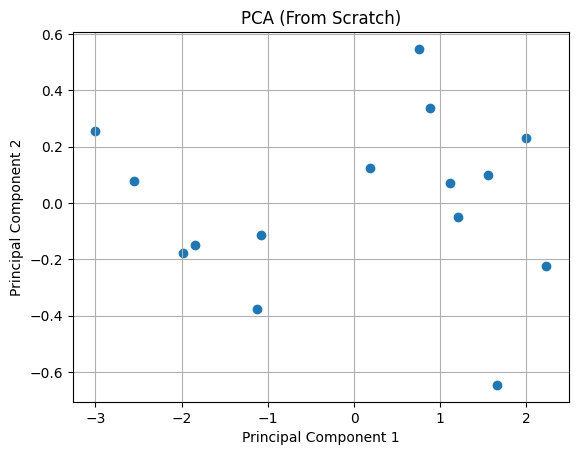


Sklearn PCA Result:
 [[-1.6616261  -0.64623275]
 [-1.20690058 -0.04975621]
 [-0.75217506  0.54672032]
 [ 1.12954916 -0.37502849]
 [ 1.84306259 -0.14937029]
 [ 2.55657602  0.07628791]
 [-2.23096513 -0.22434076]
 [-1.99804475  0.22973943]
 [-0.88157465  0.33822114]
 [ 1.98247224 -0.17947824]
 [ 2.99945325  0.25682548]
 [-1.55736663  0.09751171]
 [-1.11595547  0.06953909]
 [-0.18283602  0.12482833]
 [ 1.07633113 -0.11546667]]

Sklearn Explained Variance:
 [0.96729695 0.02770459]


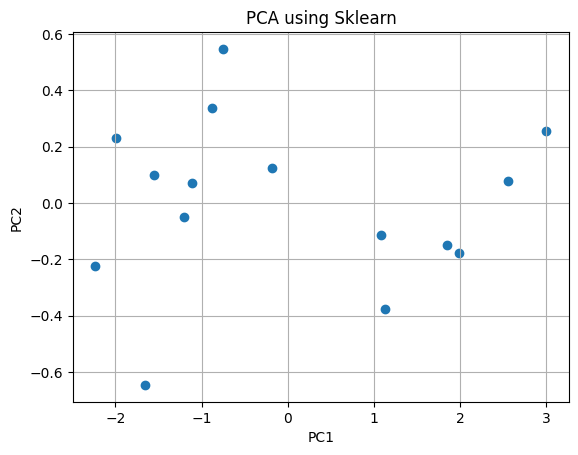

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# STEP 1: CREATE DATASET
# =========================
data = pd.DataFrame({
    "Age": [25,30,35,40,45,50,23,27,33,48,52,29,31,37,42],
    "Income": [40000,50000,60000,80000,90000,100000,38000,42000,58000,85000,110000,46000,52000,62000,78000],
    "SpendingScore": [60,65,70,30,25,20,75,80,68,22,18,72,66,55,35]
})

print("Original Data:\n")
print(data)

# Convert to numpy
X = data.values


# =========================
# STEP 2: STANDARDIZE DATA
# =========================
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_standardized = (X - mean) / std

print("\nMean:\n", mean)
print("\nStandard Deviation:\n", std)
print("\nStandardized Data:\n", X_standardized)


# =========================
# STEP 3: COVARIANCE MATRIX
# =========================
cov_matrix = np.cov(X_standardized, rowvar=False)

print("\nCovariance Matrix:\n", cov_matrix)


# =========================
# STEP 4: EIGEN VALUES & VECTORS
# =========================
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


# =========================
# STEP 5: SORT EIGENVALUES
# =========================
sorted_indices = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", sorted_eigenvalues)
print("\nSorted Eigenvectors:\n", sorted_eigenvectors)


# =========================
# STEP 6: SELECT TOP K COMPONENTS
# =========================
k = 2
W = sorted_eigenvectors[:, :k]

print("\nSelected Top K Eigenvectors (W):\n", W)


# =========================
# STEP 7: PROJECT DATA
# =========================
X_reduced = np.dot(X_standardized, W)

print("\nReduced Data (After PCA):\n", X_reduced)


# =========================
# STEP 8: EXPLAINED VARIANCE
# =========================
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

print("\nExplained Variance Ratio:\n", explained_variance)


# =========================
# STEP 9: VISUALIZATION
# =========================
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA (From Scratch)")
plt.grid()
plt.show()


# =========================
# STEP 10: COMPARE WITH SKLEARN
# =========================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_lib = pca.fit_transform(X_scaled)

print("\nSklearn PCA Result:\n", X_lib)
print("\nSklearn Explained Variance:\n", pca.explained_variance_ratio_)


# =========================
# STEP 11: VISUALIZE SKLEARN PCA
# =========================
plt.scatter(X_lib[:, 0], X_lib[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA using Sklearn")
plt.grid()
plt.show()